In [8]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("mobile_device_usage.csv")
df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


In [14]:
df.describe()

,User ID,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,271.128571,5.272714,1525.158571,50.681429,929.742857,38.482857,2.990000
std,202.21688,177.199484,3.068584,819.136414,26.943324,640.451729,12.012916,1.401476
min,1.00000,30.000000,1.000000,302.000000,10.000000,102.000000,18.000000,1.000000
25%,175.75000,113.250000,2.500000,722.250000,26.000000,373.000000,28.000000,2.000000
50%,350.50000,227.500000,4.900000,1502.500000,49.000000,823.500000,38.000000,3.000000
75%,525.25000,434.250000,7.400000,2229.500000,74.000000,1341.000000,49.000000,4.000000
max,700.00000,598.000000,12.000000,2993.000000,99.000000,2497.000000,59.000000,5.000000


In [17]:
df.isnull().sum

<bound method DataFrame.sum of      User ID  Device Model  Operating System  App Usage Time (min/day)  \
0      False         False             False                     False   
1      False         False             False                     False   
2      False         False             False                     False   
3      False         False             False                     False   
4      False         False             False                     False   
..       ...           ...               ...                       ...   
695    False         False             False                     False   
696    False         False             False                     False   
697    False         False             False                     False   
698    False         False             False                     False   
699    False         False             False                     False   

     Screen On Time (hours/day)  Battery Drain (mAh/day)  \
0                   

In [19]:
#filling numeric missing values with median
df.fillna(df.median(numeric_only = True), inplace = True)

#filling categorical missing values with most frequent value
for col in df.select_dtypes(include = 'object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [22]:
#encoding categorical columns (gender, OS etc into numbers)
from sklearn.preprocessing import LabelEncoder 

lb = LabelEncoder()

for col in df.select_dtypes(include = 'object').columns:
    df[col] = lb.fit_transform(df[col])

In [23]:
df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,0,0,393,6.4,1872,67,1122,40,1,4
1,2,1,0,268,4.7,1331,42,944,47,0,3
2,3,3,0,154,4.0,761,32,322,42,1,2
3,4,0,0,239,4.8,1676,56,871,20,1,3
4,5,4,1,187,4.3,1367,58,988,31,0,3


In [26]:
#scaling data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = df.drop("User Behavior Class", axis = 1).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [27]:
df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,-1.729578,-1.420106,-0.513359,0.688256,0.367626,0.423726,0.606096,0.300405,0.126383,0.960769,4
1,-1.724629,-0.720547,-0.513359,-0.017668,-0.186771,-0.237198,-0.322441,0.022277,0.709506,-1.040833,3
2,-1.719681,0.678573,-0.513359,-0.661471,-0.415053,-0.933550,-0.693856,-0.949607,0.292989,0.960769,2
3,-1.714732,-1.420106,-0.513359,-0.181443,-0.154160,0.184279,0.197540,-0.091787,-1.539682,0.960769,3
4,-1.709783,1.378133,1.947953,-0.475107,-0.317218,-0.193218,0.271823,0.091028,-0.623346,-1.040833,3


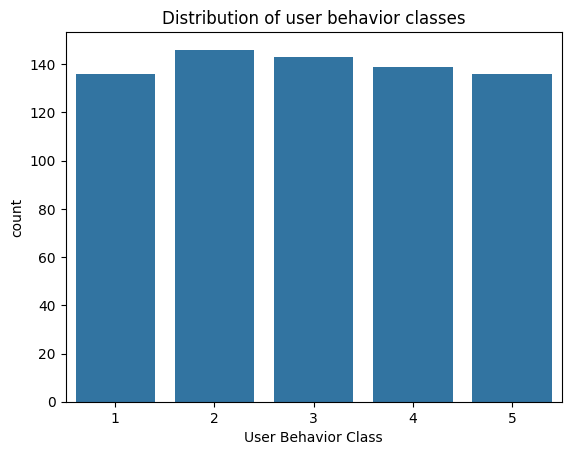

In [29]:
# distribution of user behaviour class

sns.countplot( x = 'User Behavior Class', data=df)
plt.title("Distribution of user behavior classes")
plt.show()

In [33]:
# average screen time per behavior class 

df.groupby('User Behavior Class')['Screen On Time (hours/day)'].mean()

User Behavior Class
1   -1.233461
2   -0.728884
3   -0.103304
4    0.533734
5    1.579052
Name: Screen On Time (hours/day), dtype: float64

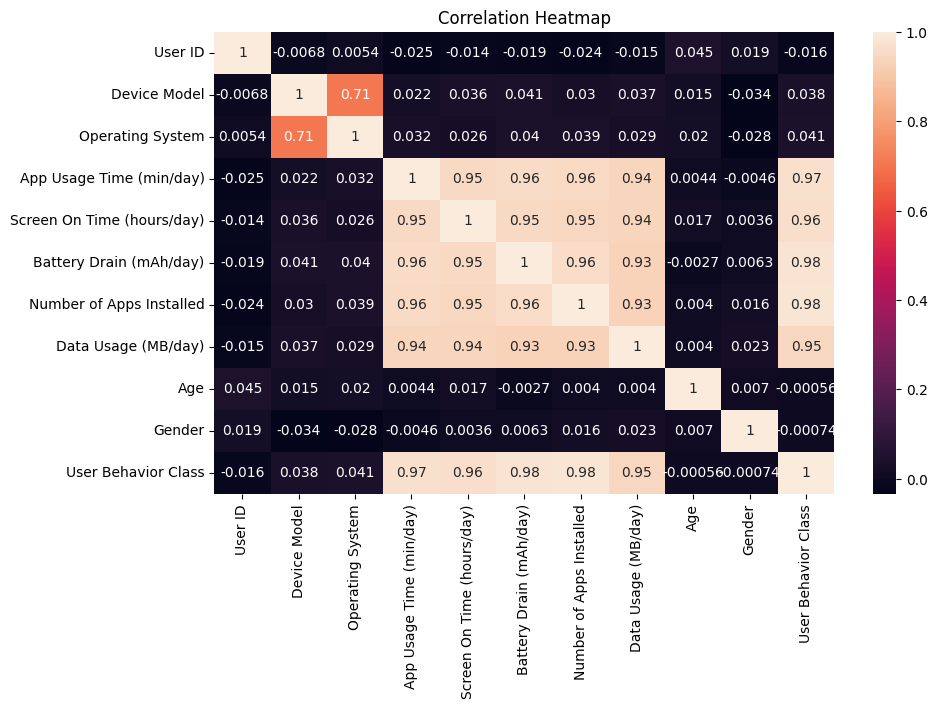

In [34]:
#corelation heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot = True)
plt.title("Correlation Heatmap")
plt.show()

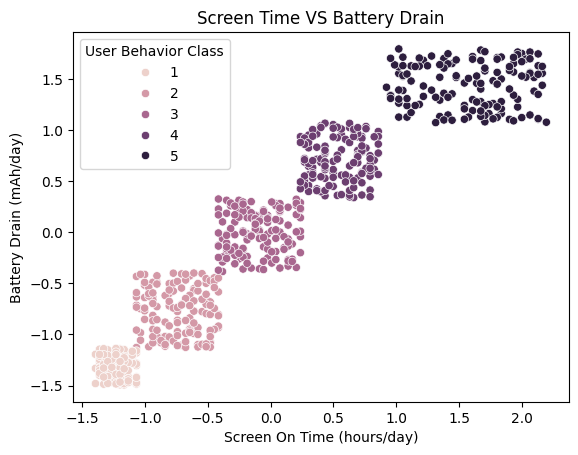

In [39]:
# after analaysing the above heatmap creating a screen time vs battery drain

sns.scatterplot(x = 'Screen On Time (hours/day)', y = 'Battery Drain (mAh/day)', hue = 'User Behavior Class', data = df)
plt.title("Screen Time VS Battery Drain")
plt.show()

In [38]:
df.columns


Index(['User ID', 'Device Model', 'Operating System',
       'App Usage Time (min/day)', 'Screen On Time (hours/day)',
       'Battery Drain (mAh/day)', 'Number of Apps Installed',
       'Data Usage (MB/day)', 'Age', 'Gender', 'User Behavior Class'],
      dtype='object')

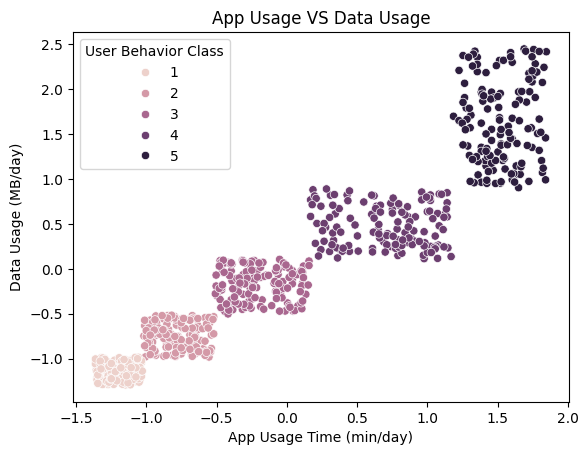

In [40]:
#app usage VS data consumption 

sns.scatterplot(x = 'App Usage Time (min/day)', y = 'Data Usage (MB/day)', hue = 'User Behavior Class', data = df)
plt.title("App Usage VS Data Usage")
plt.show()

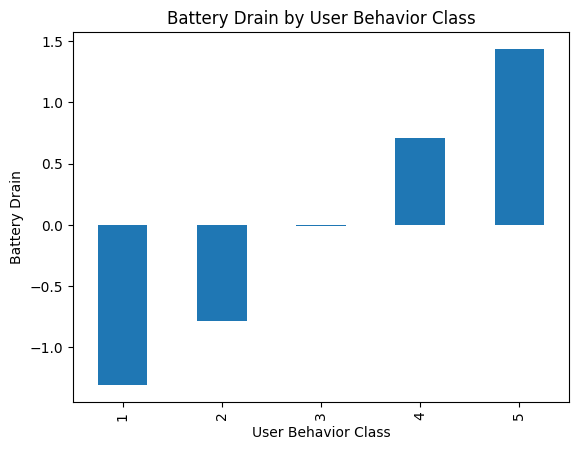

In [42]:
df.groupby('User Behavior Class')['Battery Drain (mAh/day)'].mean().plot(kind = 'bar')
plt.title("Battery Drain by User Behavior Class")
plt.ylabel("Battery Drain")
plt.show()

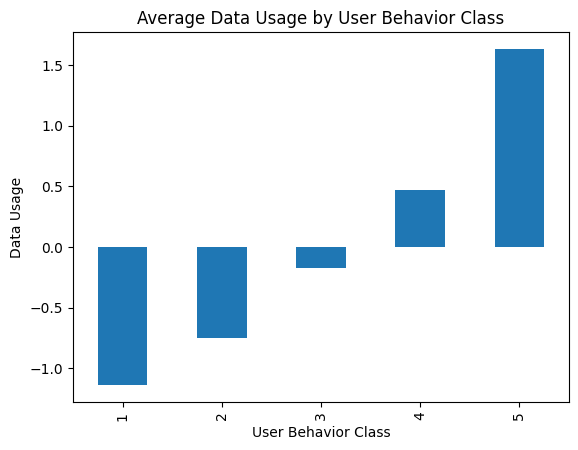

In [43]:
df.groupby('User Behavior Class')['Data Usage (MB/day)'].mean().plot(kind = 'bar')
plt.title("Average Data Usage by User Behavior Class")
plt.ylabel("Data Usage")
plt.show()

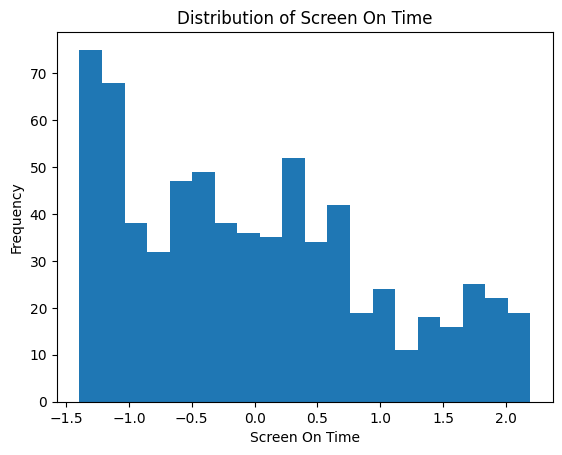

In [44]:
plt.hist(df['Screen On Time (hours/day)'], bins = 20)
plt.title("Distribution of Screen On Time")
plt.xlabel("Screen On Time")
plt.ylabel("Frequency")
plt.show()

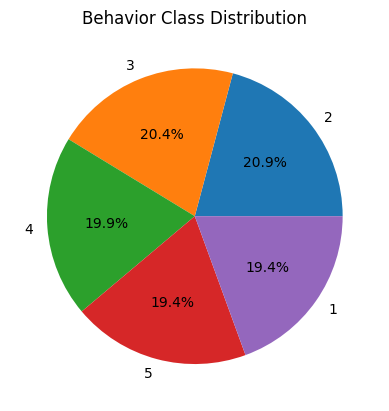

In [45]:
df['User Behavior Class'].value_counts().plot(kind = 'pie', autopct = '%1.1f%%')
plt.title("Behavior Class Distribution")
plt.ylabel("")
plt.show()

In [48]:
#separating input features and target variable for supervised learning 
X = df.drop('User Behavior Class', axis = 1)
y = df['User Behavior Class']

In [55]:
# spliting data for training the model and testing (80-20)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [56]:
#training logistic regression 

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter = 1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [57]:
#training decision tree 

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [58]:
#training K Nearest Neighbour (KNN)

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

In [59]:
#checking accuracy 

from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("Decision Tree:", accuracy_score(y_test, dt_pred))
print("KNN:", accuracy_score(y_test, knn_pred))

Logistic Regression: 1.0
Decision Tree: 0.9928571428571429
KNN: 0.9714285714285714


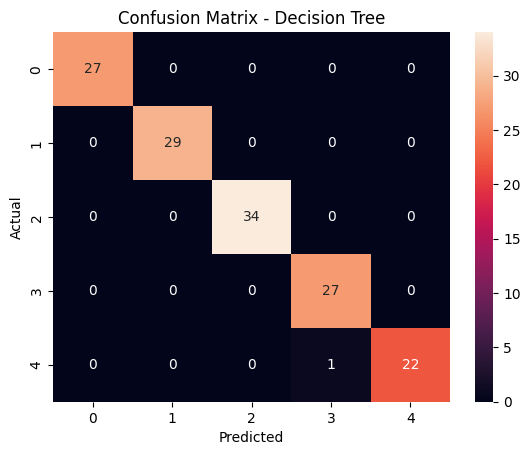

In [60]:
#confusion matrix

from sklearn.metrics import confusion_matrix 
import seaborn as sns 
import matplotlib.pyplot as plt 

cm = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm, annot = True, fmt = 'd')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [61]:
# training model

from sklearn.ensemble import RandomForestClassifier 

model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [62]:
#making predictions 

y_pred = model.predict(X_test)

In [66]:
from sklearn.metrics import accuracy_score 

accuracy_score(y_test, y_pred)

1.0

In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        29
           3       1.00      1.00      1.00        34
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        23

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name} Accuracy: {acc:.3f}")

Logistic Regression Accuracy: 1.000
Decision Tree Accuracy: 1.000
KNN Accuracy: 0.971


In [70]:
import pandas as pd

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results.append([name, acc])

pd.DataFrame(results, columns=["Model", "Accuracy"])

,Model,Accuracy
0,Logistic Regression,1.000000
1,Decision Tree,0.992857
2,KNN,0.971429
